In [404]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score as pr, recall_score as recall
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier


from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# **Parte 1: lectura de pb2020-2025**

In [405]:
df_pib = pd.read_csv('data_2025/pib2020-2025.csv')
df_pib.head()

,Country,2020,2021,2022,2023,2024,2025
0,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN
1,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0
2,Algeria,164774,185850.0,225709.0,247789.0,264913.0,268885.0
3,Andorra,2885,3325.0,3376.0,3786.0,4038.0,4035.0
4,Angola,66521,84375.0,142442.0,109764.0,115946.0,113343.0


In [406]:
df_pib.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  196 non-null    object 
 1   2020     196 non-null    int64  
 2   2021     194 non-null    float64
 3   2022     194 non-null    float64
 4   2023     194 non-null    float64
 5   2024     192 non-null    float64
 6   2025     189 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 10.8+ KB


Notemos que tiene datos nulos en algunas columnas. Investiguemos si son de naturaleza MCAR, MAR o MNAR.

In [407]:
print(df_pib.isnull().sum())
filas_con_nulos = df_pib[df_pib.isnull().any(axis=1)]
print(filas_con_nulos.head(50)) # Head 50 es una exageración para ver todos los datos nulos

Country    0
2020       0
2021       2
2022       2
2023       2
2024       4
2025       7
dtype: int64
         Country    2020      2021      2022      2023      2024  2025
0    Afghanistan   20136   14278.0   14501.0   17248.0       NaN   NaN
54       Eritrea    1982       NaN       NaN       NaN       NaN   NaN
96       Lebanon   24976   19782.0   24748.0   23607.0   28280.0   NaN
131     Pakistan  300410  348481.0  374850.0  337754.0  373078.0   NaN
161    Sri Lanka   84304   88609.0   74584.0   83723.0   98964.0   NaN
169        Syria   60043       NaN       NaN       NaN       NaN   NaN
192    Palestine   15532   18109.0   19166.0   17848.0       NaN   NaN


In [408]:
# Veamos el porcentaje de los datos nulos por columna
null_sum = df_pib.isna().sum()
total = null_sum.sort_values(ascending=False)
percent = ( ((null_sum / len(df_pib.index))*100).round(2) ).sort_values(ascending=False)
df_NA = pd.concat([total, percent], axis=1, keys=['Number of NA', 'Percent NA'])
df_NA.head()

,Number of NA,Percent NA
2025,7,3.57
2024,4,2.04
2021,2,1.02
2023,2,1.02
2022,2,1.02


Notemos que los países que faltan datos tienen al menos uno de los siguientes problemas en los años con datos NaN o siguientes: cambio de gobierno, datos limitados internacionales, crisis económicas, inestabilidad económica, guerra civil y/o conflicto geopolítico. Por lo tanto, recaen en la categoría MNAR (Missing not at random).

Como los datos no pueden ser predichos con exactitud, y reemplazar el estas columnas con un 0 por ejemplo, llevaría a una variación demasiado significativa en cálculos generales, se decide eliminar estos países debido a que su porcentaje con respecto a los otros países es bastante bajo (< 4%).

O, eliminamos la columna de 2025, y aquellos países que tengan dato NaN del PIB antes de 2025.

In [409]:
# DF eliminando los países con datos nulos

paises_a_eliminar = ['Afghanistan', 'Eritrea', 'Lebanon', 'Pakistan', 'Sri Lanka', 'Syria', 'Palestine']

pib_clean_nan = df_pib[~df_pib['Country'].isin(paises_a_eliminar)].copy()
pib_clean_nan.reset_index(drop=True, inplace=True)

print(pib_clean_nan.isnull().sum())
pib_clean_nan.head()

Country    0
2020       0
2021       0
2022       0
2023       0
2024       0
2025       0
dtype: int64


,Country,2020,2021,2022,2023,2024,2025
0,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0
1,Algeria,164774,185850.0,225709.0,247789.0,264913.0,268885.0
2,Andorra,2885,3325.0,3376.0,3786.0,4038.0,4035.0
3,Angola,66521,84375.0,142442.0,109764.0,115946.0,113343.0
4,Antigua and Barbuda,1412,1602.0,1867.0,2006.0,2225.0,2373.0


In [410]:
# Dataframe eliminando la columna 2025 y aquellos países que tengan dato NaN del PIB antes de 2025
pib_sin_2025 = df_pib.drop(columns='2025')
paises_a_eliminar = pib_sin_2025[pib_sin_2025.isnull().any(axis=1)]['Country'].tolist()
pib_clean_sin2025 = pib_sin_2025[~pib_sin_2025['Country'].isin(paises_a_eliminar)].copy()
pib_clean_sin2025.reset_index(drop=True, inplace=True)

print(pib_clean_sin2025.isnull().sum())
pib_clean_sin2025.head()

Country    0
2020       0
2021       0
2022       0
2023       0
2024       0
dtype: int64


,Country,2020,2021,2022,2023,2024
0,Albania,15271,18086.0,19185.0,23388.0,27259.0
1,Algeria,164774,185850.0,225709.0,247789.0,264913.0
2,Andorra,2885,3325.0,3376.0,3786.0,4038.0
3,Angola,66521,84375.0,142442.0,109764.0,115946.0
4,Antigua and Barbuda,1412,1602.0,1867.0,2006.0,2225.0


In [411]:
# Veamos si existen datos duplicados

duplicates = pib_clean_nan[pib_clean_nan.duplicated()]
duplicates.head()

,Country,2020,2021,2022,2023,2024,2025


No existen. Con esto hemos completado la limpieza principal.

In [412]:
# Adicional: haz el promedio del PIB de los países POR país en el dataset limpio
pib_promedio = pib_clean_nan.copy()
pib_promedio['Promedio PIB'] = pib_promedio.loc[:, '2020':'2025'].mean(axis=1)
pib_promedio.head()

,Country,2020,2021,2022,2023,2024,2025,Promedio PIB
0,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,21926.833333
1,Algeria,164774,185850.0,225709.0,247789.0,264913.0,268885.0,226320.000000
2,Andorra,2885,3325.0,3376.0,3786.0,4038.0,4035.0,3574.166667
3,Angola,66521,84375.0,142442.0,109764.0,115946.0,113343.0,105398.500000
4,Antigua and Barbuda,1412,1602.0,1867.0,2006.0,2225.0,2373.0,1914.166667


In [413]:
# Adicional: 'Toma solo países x'
pib_rango = pib_clean_nan.copy()
pib_rango = pib_rango[pib_rango['Country'].isin(['Chile', 'Argentina', 'Brazil'])]
pib_rango = pib_rango.reset_index(drop=True)
pib_rango.head()

,Country,2020,2021,2022,2023,2024,2025
0,Argentina,385218,486040.0,632318.0,645511.0,632145.0,683533.0
1,Brazil,1476092,1670650.0,1951849.0,2191137.0,2171337.0,2125958.0
2,Chile,254060,315411.0,301270.0,335627.0,330210.0,343823.0


In [414]:
# Adicional: filtra en los años 2020-2022
pib_2020_2022 = pib_clean_nan.loc[:, ['Country', '2020', '2021', '2022']]
pib_2020_2022.head()

,Country,2020,2021,2022
0,Albania,15271,18086.0,19185.0
1,Algeria,164774,185850.0,225709.0
2,Andorra,2885,3325.0,3376.0
3,Angola,66521,84375.0,142442.0
4,Antigua and Barbuda,1412,1602.0,1867.0


# **Parte 2: EDA de pib**

In [415]:
# Evolución del PIB global por año
print('EVOLUCIÓN TEMPORAL DEL PIB GLOBAL:')

pib_por_año = pib_clean_nan[['2020', '2021', '2022', '2023', '2024', '2025']].sum()
print("PIB total por año:")
for año, pib_total in pib_por_año.items():
    print(f"  {año}: {pib_total:,.0f}")

# Crecimiento porcentual año a año
print("\nCrecimiento porcentual año a año:")
for i in range(1, len(pib_por_año)):
    crecimiento = ((pib_por_año.iloc[i] - pib_por_año.iloc[i-1]) / pib_por_año.iloc[i-1]) * 100
    print(f"  {pib_por_año.index[i-1]} - {pib_por_año.index[i]}: {crecimiento:.2f}%")

EVOLUCIÓN TEMPORAL DEL PIB GLOBAL:
PIB total por año:
  2020: 85,318,790
  2021: 97,354,726
  2022: 101,440,389
  2023: 105,951,573
  2024: 110,031,596
  2025: 113,237,734

Crecimiento porcentual año a año:
  2020 - 2021: 14.11%
  2021 - 2022: 4.20%
  2022 - 2023: 4.45%
  2023 - 2024: 3.85%
  2024 - 2025: 2.91%


C:\Users\isimo\AppData\Local\Temp\ipykernel_15672\2984013455.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot([pib_boxplot[col].dropna() for col in pib_boxplot.columns],


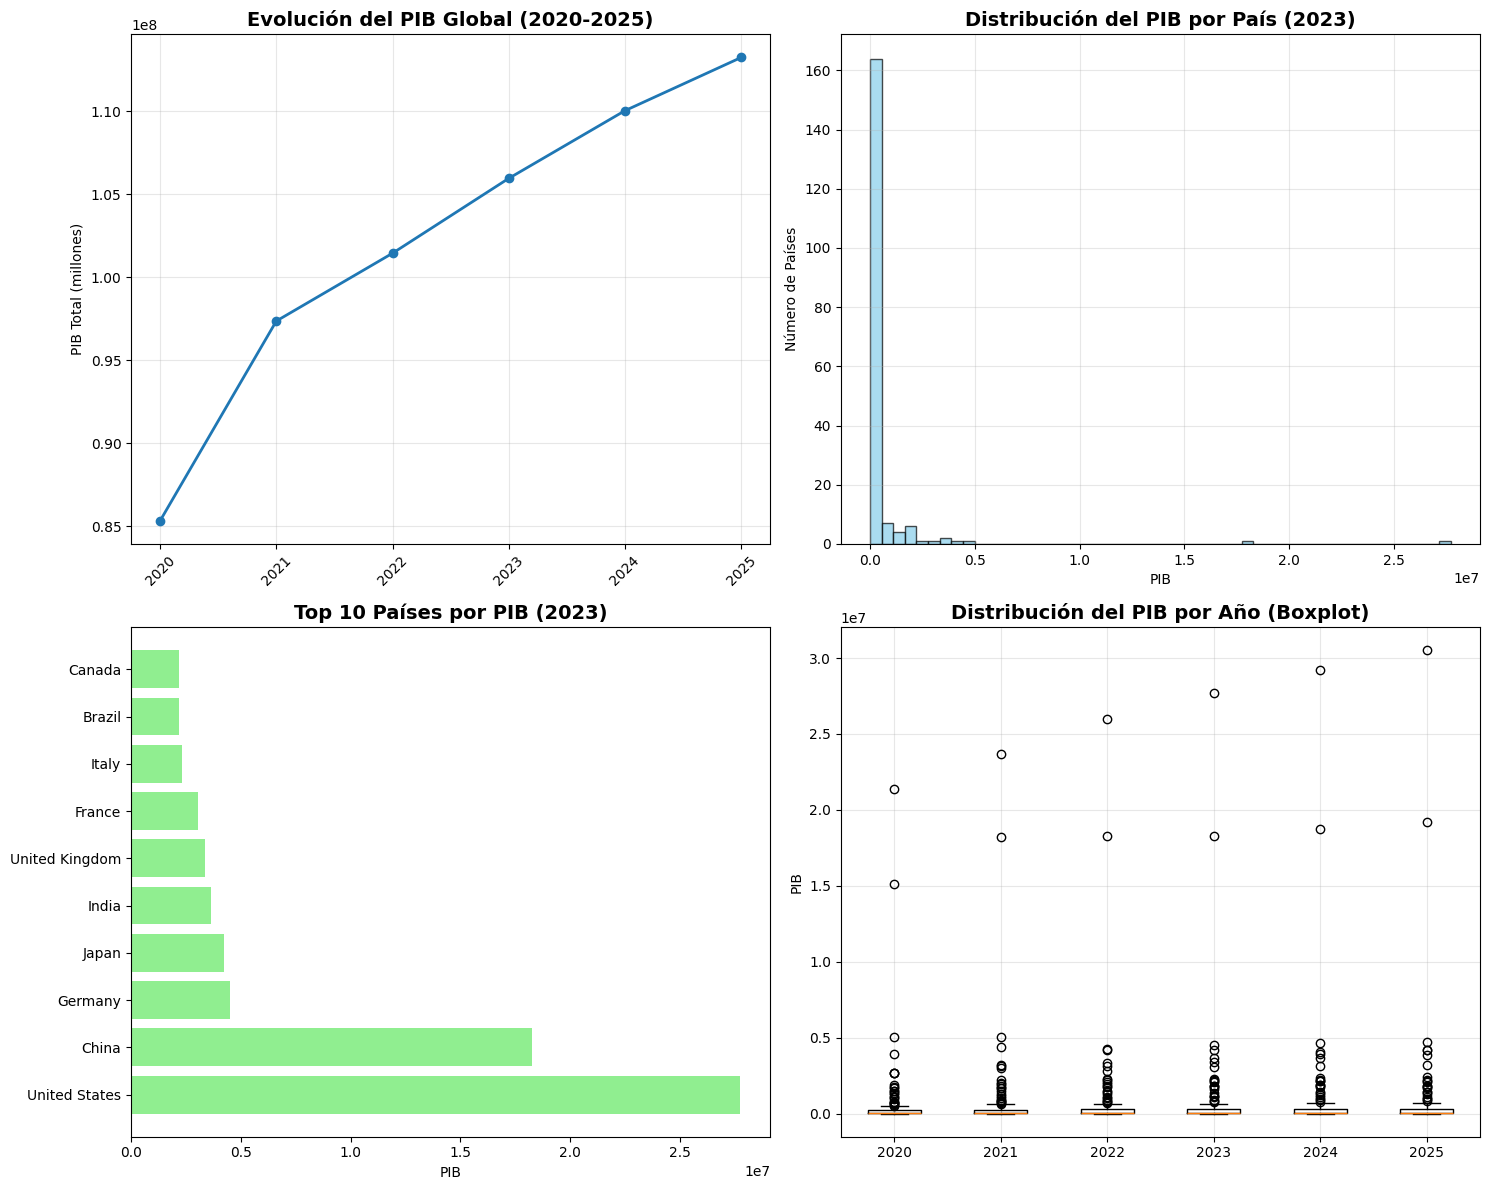

In [416]:
# Configurar estilo
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gráfico 1: Evolución del PIB global
axes[0,0].plot(pib_por_año.index, pib_por_año.values, marker='o', linewidth=2, markersize=6)
axes[0,0].set_title('Evolución del PIB Global (2020-2025)', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('PIB Total (millones)')
axes[0,0].grid(True, alpha=0.3)
axes[0,0].tick_params(axis='x', rotation=45)

# Gráfico 2: Distribución del PIB en 2023 (año más reciente completo)
axes[0,1].hist(pib_clean_nan['2023'].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,1].set_title('Distribución del PIB por País (2023)', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('PIB')
axes[0,1].set_ylabel('Número de Países')
axes[0,1].grid(True, alpha=0.3)

# Gráfico 3: Top 10 países por PIB en 2023
top_10_2023 = pib_clean_nan.nlargest(10, '2023')[['Country', '2023']]
axes[1,0].barh(top_10_2023['Country'], top_10_2023['2023'], color='lightgreen')
axes[1,0].set_title('Top 10 Países por PIB (2023)', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('PIB')

# Gráfico 4: Boxplot del PIB por año
pib_boxplot = pib_clean_nan[['2020', '2021', '2022', '2023', '2024', '2025']]
axes[1,1].boxplot([pib_boxplot[col].dropna() for col in pib_boxplot.columns], 
                 labels=pib_boxplot.columns)
axes[1,1].set_title('Distribución del PIB por Año (Boxplot)', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('PIB')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [417]:
print("ANÁLISIS DE VALORES ATÍPICOS:")

# Identificar países con PIB excepcionalmente alto o bajo en 2025
Q1 = pib_clean_nan['2025'].quantile(0.25)
Q3 = pib_clean_nan['2025'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificar outliers 2025
outliers_bajos = pib_clean_nan[pib_clean_nan['2025'] < limite_inferior]
outliers_altos = pib_clean_nan[pib_clean_nan['2025'] > limite_superior]

print(f"Límite inferior para outliers: {limite_inferior:,.0f}")
print(f"Límite superior para outliers: {limite_superior:,.0f}")
print(f"Países con PIB muy bajo (outliers): {len(outliers_bajos)}")
print(f"Países con PIB muy alto (outliers): {len(outliers_altos)}")

if len(outliers_altos) > 0:
    print("\nPaíses con PIB excepcionalmente alto:")
    print(outliers_altos[['Country', '2025']])

ANÁLISIS DE VALORES ATÍPICOS:
Límite inferior para outliers: -419,404
Límite superior para outliers: 736,912
Países con PIB muy bajo (outliers): 0
Países con PIB muy alto (outliers): 22

Países con PIB excepcionalmente alto:
            Country        2025
8         Australia   1771681.0
23           Brazil   2125958.0
31           Canada   2225341.0
35            China  19231705.0
58           France   3211292.0
62          Germany   4744804.0
75            India   4187017.0
76        Indonesia   1429743.0
81            Italy   2422855.0
83            Japan   4186431.0
88      South Korea   1790322.0
109          Mexico   1692640.0
120     Netherlands   1272011.0
134          Poland    979960.0
139          Russia   2076396.0
144    Saudi Arabia   1083749.0
156           Spain   1799511.0
163     Switzerland    947125.0
164          Taiwan    804889.0
173          Turkey   1437406.0
179  United Kingdom   3839180.0
180   United States  30507217.0


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, '2020'),
  Text(1, 0, '2021'),
  Text(2, 0, '2022'),
  Text(3, 0, '2023'),
  Text(4, 0, '2024'),
  Text(5, 0, '2025')])

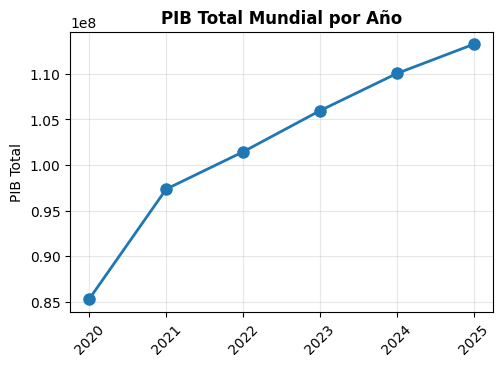

In [418]:
plt.figure(figsize=(12, 8))

# Subplot 1: Evolución del PIB global
plt.subplot(2, 2, 1)
pib_total_por_año = pib_clean_nan[['2020', '2021', '2022', '2023', '2024', '2025']].sum()
plt.plot(pib_total_por_año.index, pib_total_por_año.values, marker='o', linewidth=2, markersize=8)
plt.title('PIB Total Mundial por Año', fontweight='bold')
plt.ylabel('PIB Total')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

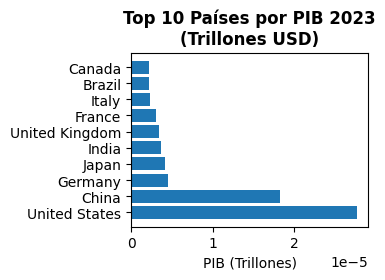

In [419]:
plt.subplot(2, 2, 2)
top_10 = pib_clean_nan.nlargest(10, '2023')[['Country', '2023']]
plt.barh(top_10['Country'], top_10['2023'] / 1e12)  # En trillones para mejor escala
plt.title('Top 10 Países por PIB 2023\n(Trillones USD)', fontweight='bold')
plt.xlabel('PIB (Trillones)')
plt.tight_layout()

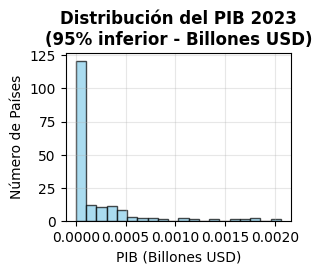

In [420]:
# Subplot 3: Histograma simple del PIB 2023
plt.subplot(2, 2, 3)
# Filtrar valores extremos para mejor visualización
pib_2023_filtrado = pib_clean_nan['2023'][pib_clean_nan['2023'] < pib_clean_nan['2023'].quantile(0.95)]
plt.hist(pib_2023_filtrado / 1e9, bins=20, alpha=0.7, color='skyblue', edgecolor='black')  # En billones
plt.title('Distribución del PIB 2023\n(95% inferior - Billones USD)', fontweight='bold')
plt.xlabel('PIB (Billones USD)')
plt.ylabel('Número de Países')
plt.grid(True, alpha=0.3)

In [421]:
# Transformar a formato long para análisis temporal y ML
pib_long = pib_clean_nan.melt(
    id_vars=['Country'], 
    value_vars=['2020', '2021', '2022', '2023', '2024', '2025'],
    var_name='Year', 
    value_name='PIB'
)

# Convertir año a numérico
pib_long['Year'] = pib_long['Year'].astype(int)
pib_long = pib_long.sort_values(['Country', 'Year'])

print(f"\nDataset en formato long:")
print(f"Shape: {pib_long.shape}")
print(f"Total observaciones: {len(pib_long)}")
print(f"Rango años: {pib_long['Year'].min()} - {pib_long['Year'].max()}")
print(f"Países únicos: {pib_long['Country'].nunique()}")
print(f"Observaciones por país: {len(pib_long) / pib_long['Country'].nunique():.0f}")


Dataset en formato long:
Shape: (1134, 3)
Total observaciones: 1134
Rango años: 2020 - 2025
Países únicos: 189
Observaciones por país: 6


In [422]:
pib_long['Year'] = pib_long['Year'].astype(int)
pib_long = pib_long.sort_values(['Country', 'Year'])

print(f"\nDataset en formato long:")
print(f"Shape: {pib_long.shape}")
print(f"Total observaciones: {len(pib_long)}")
print(f"Rango años: {pib_long['Year'].min()} - {pib_long['Year'].max()}")
print(f"Países únicos: {pib_long['Country'].nunique()}")
print(f"Observaciones por país: {len(pib_long) / pib_long['Country'].nunique():.0f}")


Dataset en formato long:
Shape: (1134, 3)
Total observaciones: 1134
Rango años: 2020 - 2025
Países únicos: 189
Observaciones por país: 6


Text(2022, 6.8255032e-05, 'Crecimiento total: 32.7%')

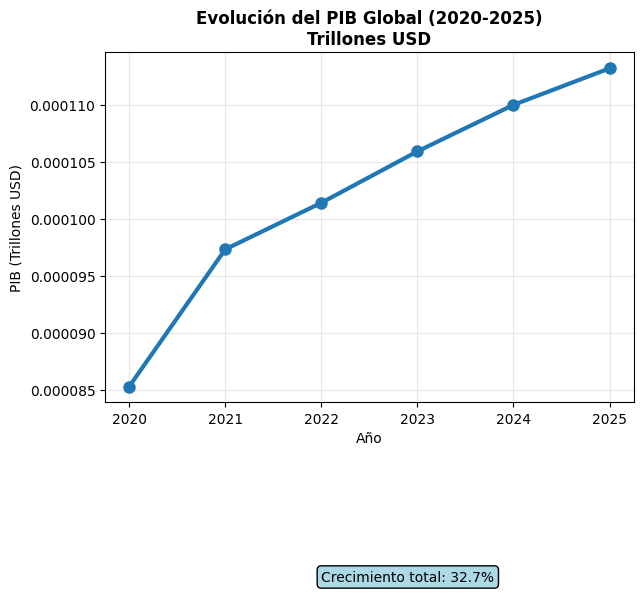

In [423]:
# Análisis de tendencias temporales
plt.figure(figsize=(15, 10))

# Gráfico 1: Evolución del PIB global
plt.subplot(2, 2, 1)
pib_global = pib_long.groupby('Year')['PIB'].sum()
plt.plot(pib_global.index, pib_global.values / 1e12, marker='o', linewidth=3, markersize=8)
plt.title('Evolución del PIB Global (2020-2025)\nTrillones USD', fontweight='bold', fontsize=12)
plt.xlabel('Año')
plt.ylabel('PIB (Trillones USD)')
plt.grid(True, alpha=0.3)

# Calcular crecimiento total
crecimiento_total = ((pib_global[2025] - pib_global[2020]) / pib_global[2020]) * 100
plt.text(2022, pib_global.min()/1e12 * 0.8, f'Crecimiento total: {crecimiento_total:.1f}%', 
         fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))

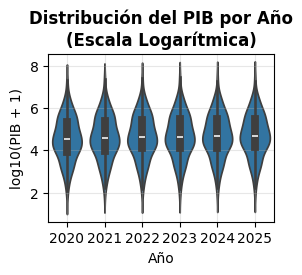

In [424]:
# Gráfico 2: Distribución del PIB por año (violin plot - mejor que boxplot)
plt.subplot(2, 2, 2)
# Usar escala logarítmica para mejor visualización
pib_long_log = pib_long.copy()
pib_long_log['log_PIB'] = np.log10(pib_long_log['PIB'] + 1)  # +1 para evitar log(0)

sns.violinplot(data=pib_long_log, x='Year', y='log_PIB')
plt.title('Distribución del PIB por Año\n(Escala Logarítmica)', fontweight='bold', fontsize=12)
plt.xlabel('Año')
plt.ylabel('log10(PIB + 1)')
plt.grid(True, alpha=0.3)

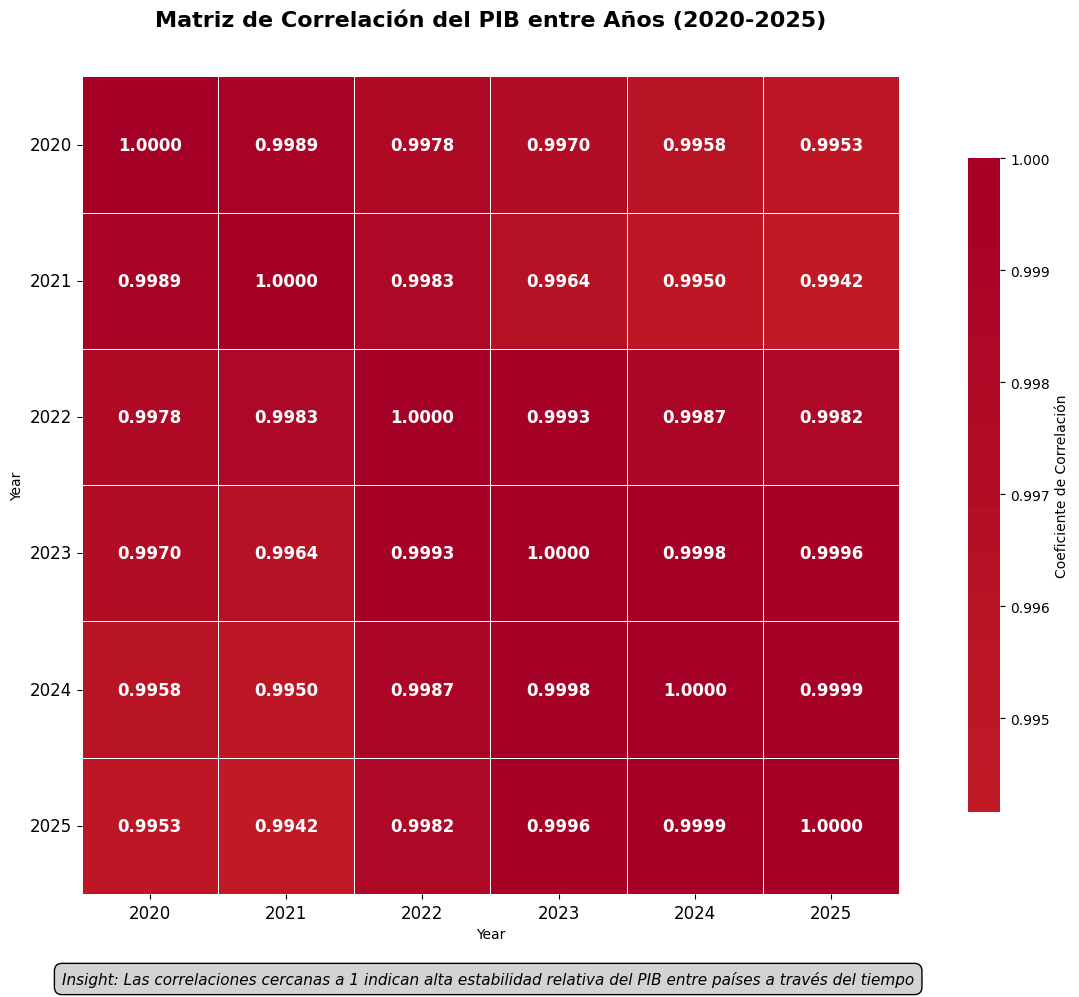

In [425]:
# Heatmap grande y detallado de correlaciones
plt.figure(figsize=(14, 10))

# Crear matriz de correlación
pib_wide = pib_long.pivot(index='Country', columns='Year', values='PIB')
correlation_matrix = pib_wide.corr()

# Heatmap con mejor visualización
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Máscara para triángulo superior

sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='RdYlBu_r',  # Mejor paleta de colores
            center=0.95,
            fmt='.4f',        # 4 decimales para más precisión
            square=True, 
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Correlación'},
            linewidths=0.5,
            linecolor='white',
            annot_kws={'size': 12, 'weight': 'bold'})

plt.title('Matriz de Correlación del PIB entre Años (2020-2025)\n', 
          fontweight='bold', fontsize=16, pad=20)
plt.xticks(fontsize=12, rotation=0)
plt.yticks(fontsize=12, rotation=0)

# Añadir insights interpretativos
plt.figtext(0.5, 0.01, 
           'Insight: Las correlaciones cercanas a 1 indican alta estabilidad relativa del PIB entre países a través del tiempo',
           ha='center', fontsize=11, style='italic', bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray"))

plt.tight_layout()
plt.subplots_adjust(bottom=0.1)  # Espacio para el texto
plt.show()

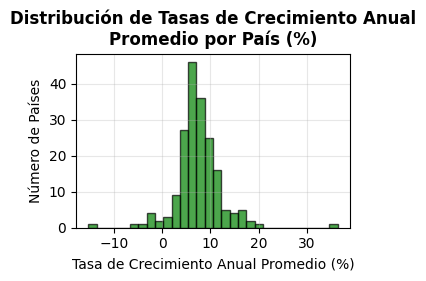

In [426]:
# Gráfico 4: Crecimiento anual promedio por país
plt.subplot(2, 2, 4)

# Calcular tasa de crecimiento anual para cada país
pib_wide_sorted = pib_wide.sort_index(axis=1)
crecimiento_promedio = []

for country in pib_wide_sorted.index:
    pib_pais = pib_wide_sorted.loc[country]
    # Calcular CAGR (Compound Annual Growth Rate)
    if len(pib_pais) > 1 and pib_pais.iloc[0] > 0:
        cagr = ((pib_pais.iloc[-1] / pib_pais.iloc[0]) ** (1/(len(pib_pais)-1)) - 1) * 100
        crecimiento_promedio.append(cagr)
    else:
        crecimiento_promedio.append(0)

# Histograma de tasas de crecimiento
plt.hist(crecimiento_promedio, bins=30, alpha=0.7, color='green', edgecolor='black')
plt.title('Distribución de Tasas de Crecimiento Anual\nPromedio por País (%)', fontweight='bold', fontsize=12)
plt.xlabel('Tasa de Crecimiento Anual Promedio (%)')
plt.ylabel('Número de Países')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

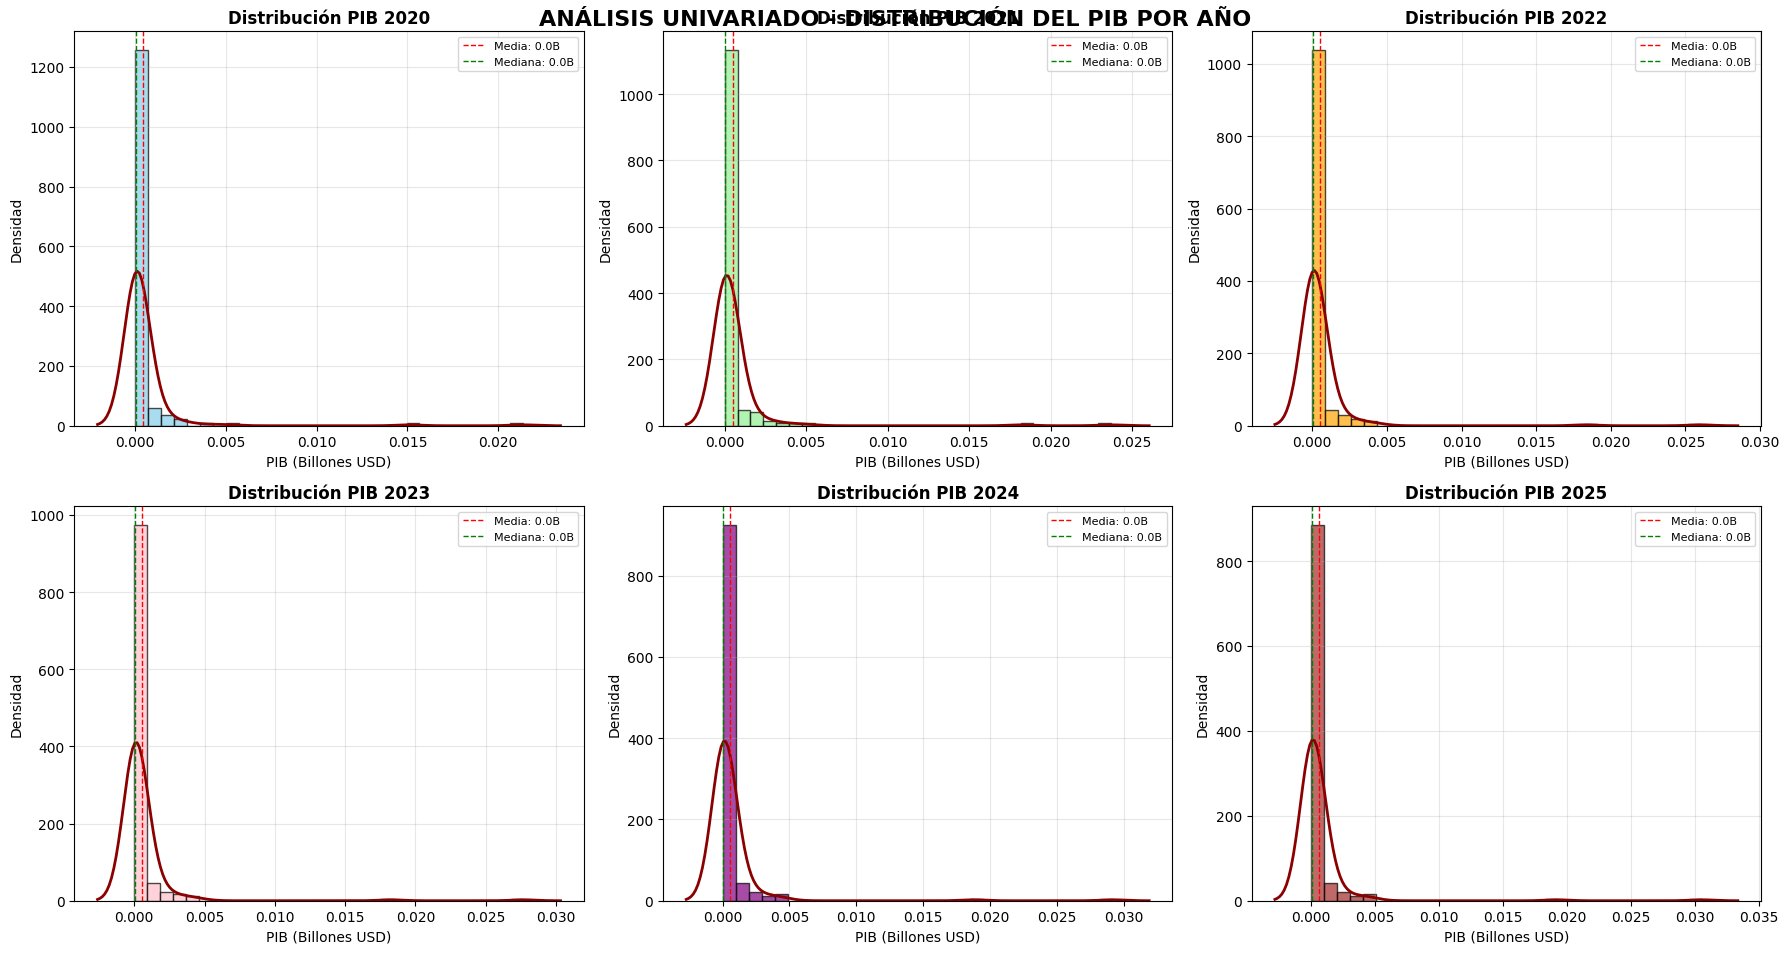

In [427]:
# Configuración inicial
plt.style.use('default')
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('ANÁLISIS UNIVARIADO - DISTRIBUCIÓN DEL PIB POR AÑO', 
             fontsize=16, fontweight='bold', y=0.95)

# Distribución por año (2020-2025)
years = ['2020', '2021', '2022', '2023', '2024', '2025']
colors = ['skyblue', 'lightgreen', 'orange', 'pink', 'purple', 'brown']

for i, year in enumerate(years):
    row = i // 3
    col = i % 3
    
    # Histograma con curva de densidad
    ax = axes[row, col]
    data = pib_clean_nan[year].dropna() / 1e9  # Convertir a billones
    
    ax.hist(data, bins=30, alpha=0.7, color=colors[i], edgecolor='black', density=True)
    
    # Añadir línea de densidad
    sns.kdeplot(data, ax=ax, color='darkred', linewidth=2)
    
    ax.set_title(f'Distribución PIB {year}', fontweight='bold')
    ax.set_xlabel('PIB (Billones USD)')
    ax.set_ylabel('Densidad')
    ax.grid(True, alpha=0.3)
    
    # Añadir estadísticas en el gráfico
    mean_val = data.mean()
    median_val = data.median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1, label=f'Media: {mean_val:.1f}B')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=1, label=f'Mediana: {median_val:.1f}B')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

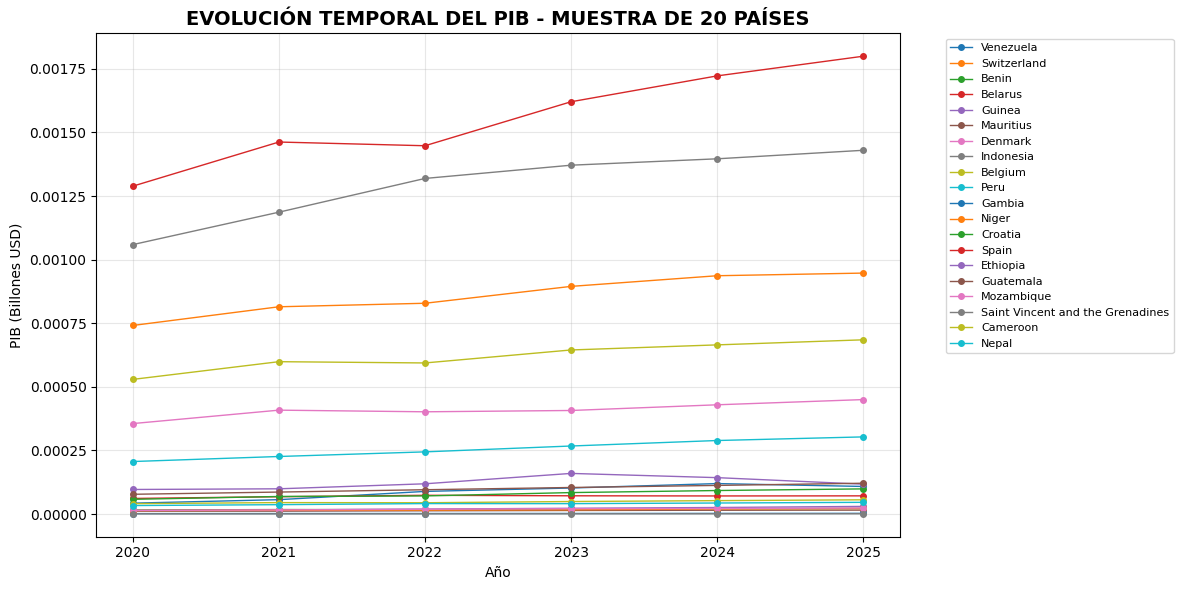

In [428]:
# Scatterplot de muestra aleatoria de países
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Seleccionar 20 países aleatorios para visualización clara
np.random.seed(42)
paises_sample = np.random.choice(pib_clean_nan['Country'], size=20, replace=False)

for pais in paises_sample:
    datos_pais = pib_clean_nan[pib_clean_nan['Country'] == pais]
    años = [2020, 2021, 2022, 2023, 2024, 2025]
    pibs = [datos_pais[str(year)].values[0] / 1e9 for year in años]  # En billones
    
    ax.plot(años, pibs, marker='o', linewidth=1, markersize=4, label=pais)

ax.set_xlabel('Año')
ax.set_ylabel('PIB (Billones USD)')
ax.set_title('EVOLUCIÓN TEMPORAL DEL PIB - MUESTRA DE 20 PAÍSES', 
             fontweight='bold', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

<Figure size 1400x1200 with 0 Axes>

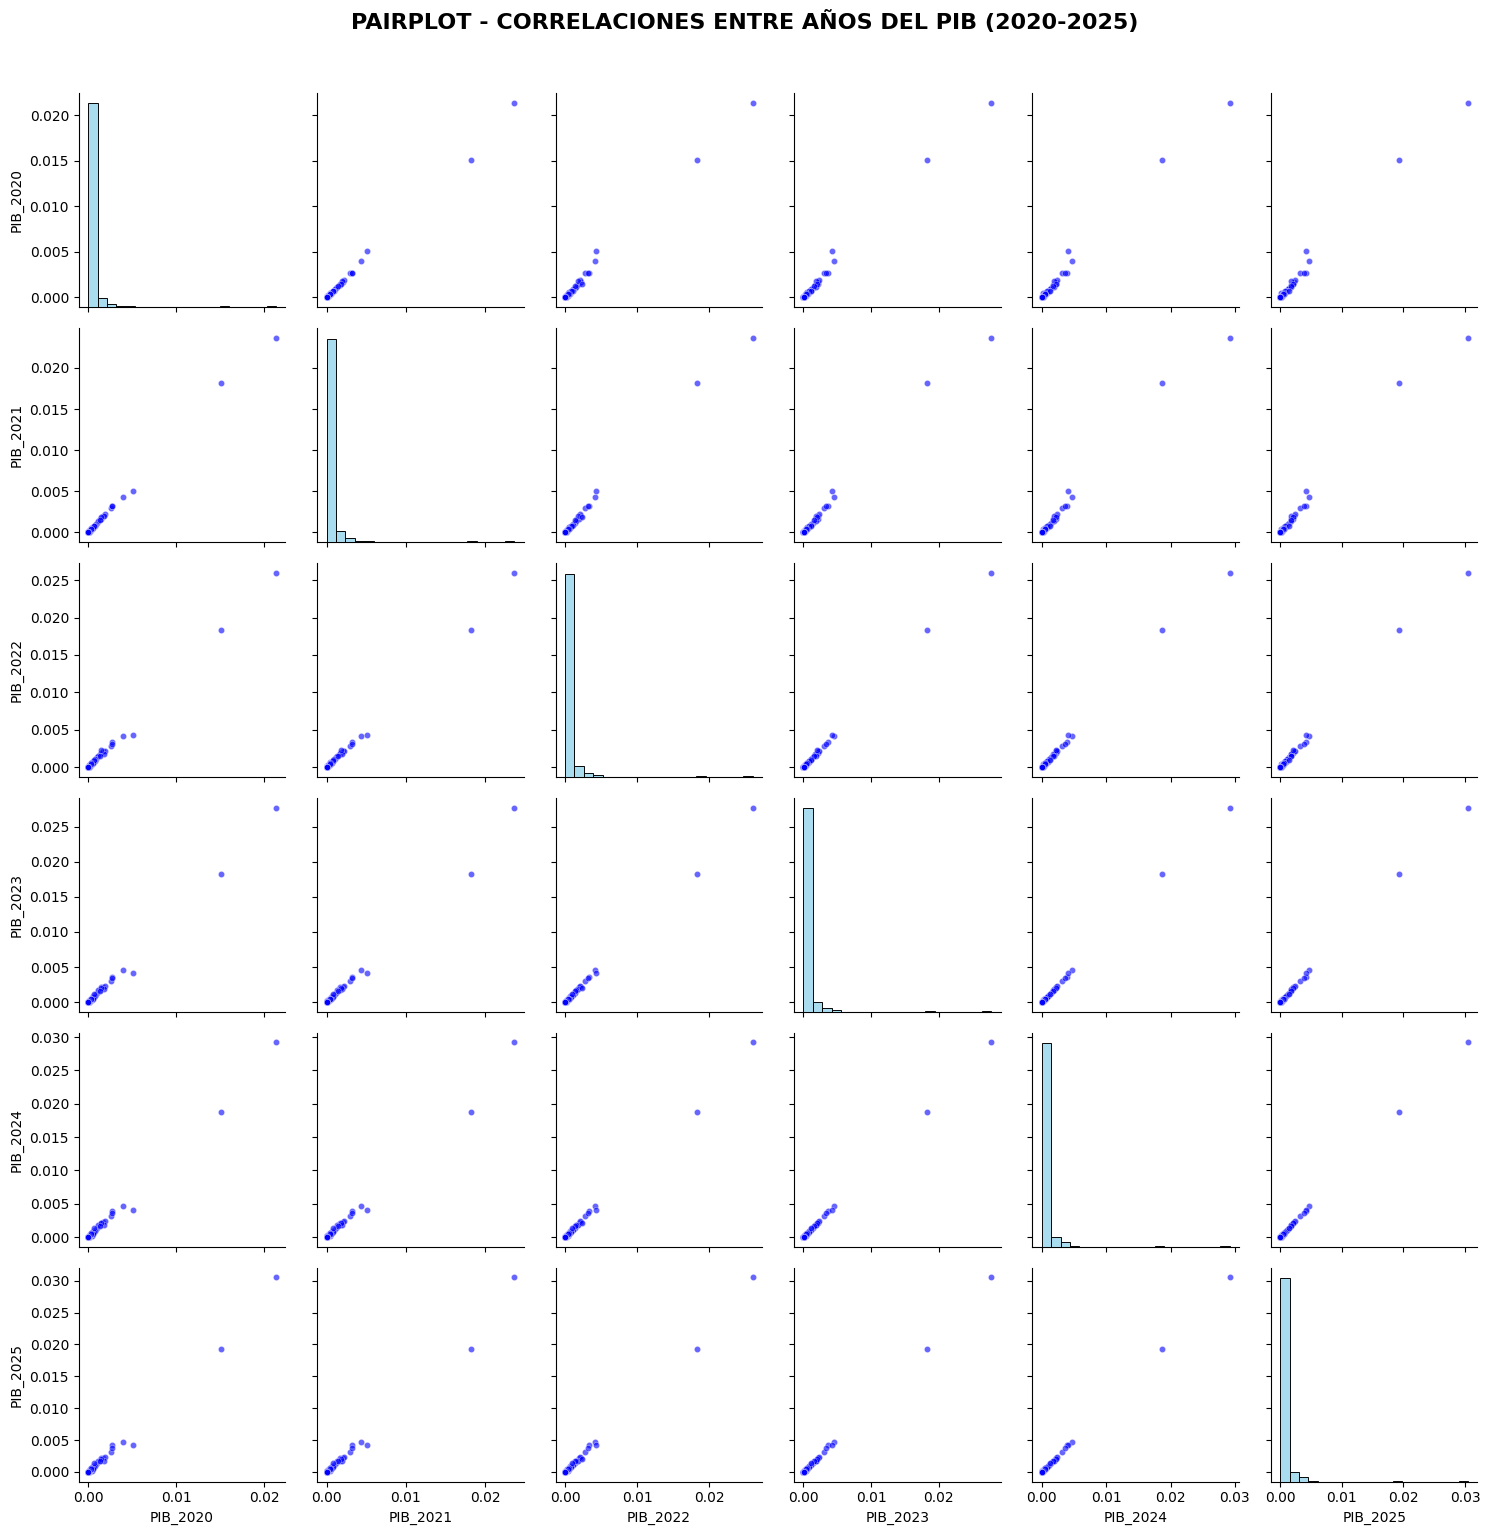


MATRIZ DE CORRELACIÓN NUMÉRICA (2020-2025):
          PIB_2020  PIB_2021  PIB_2022  PIB_2023  PIB_2024  PIB_2025
PIB_2020    1.0000    0.9989    0.9978    0.9970    0.9958    0.9953
PIB_2021    0.9989    1.0000    0.9983    0.9964    0.9950    0.9942
PIB_2022    0.9978    0.9983    1.0000    0.9993    0.9987    0.9982
PIB_2023    0.9970    0.9964    0.9993    1.0000    0.9998    0.9996
PIB_2024    0.9958    0.9950    0.9987    0.9998    1.0000    0.9999
PIB_2025    0.9953    0.9942    0.9982    0.9996    0.9999    1.0000


In [429]:
pib_pairplot = pib_clean_nan[['2020', '2021', '2022', '2023', '2024', '2025']].copy() / 1e9  # En billones
pib_pairplot.columns = [f'PIB_{year}' for year in ['2020', '2021', '2022', '2023', '2024', '2025']]

plt.figure(figsize=(14, 12))
sns.pairplot(pib_pairplot, 
             diag_kind='hist', 
             diag_kws={'alpha': 0.7, 'bins': 20, 'color': 'skyblue'},
             plot_kws={'alpha': 0.6, 's': 20, 'color': 'blue'})

plt.suptitle('PAIRPLOT - CORRELACIONES ENTRE AÑOS DEL PIB (2020-2025)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Mostrar matriz de correlación numérica por separado
print("\nMATRIZ DE CORRELACIÓN NUMÉRICA (2020-2025):")
corr_matrix = pib_pairplot.corr()
print(corr_matrix.round(4))

Esto sugiere que el tamaño relativo del PIB entre países no cambia de forma significativa año a año. El PIB global está extremadamente concentrado: pocos países generan la mayor parte del PIB (EE.UU., China, etc.), mientras que la gran mayoría tiene aportes muy pequeños. Alta correlación anual del PIB (casi perfecta). Cambios en el PIB relativo entre países son muy pequeños de un año a otro. El PIB no cambia abruptamente de un año al siguiente.

C:\Users\isimo\AppData\Local\Temp\ipykernel_15672\977505241.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, patch_artist=True,


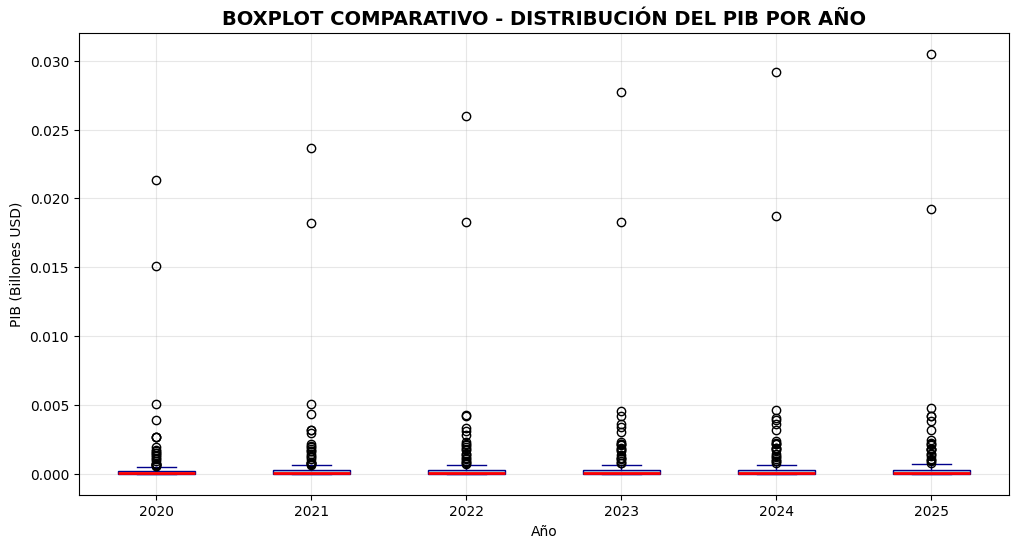

In [430]:
# Boxplot comparativo
plt.figure(figsize=(12, 6))

# Preparar datos para boxplot
boxplot_data = []
labels = []
for year in ['2020', '2021', '2022', '2023', '2024', '2025']:
    data = pib_clean_nan[year].dropna() / 1e9  # En billones
    boxplot_data.append(data)
    labels.append(year)

plt.boxplot(boxplot_data, labels=labels, patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='darkblue'),
           whiskerprops=dict(color='darkblue'),
           capprops=dict(color='darkblue'),
           medianprops=dict(color='red', linewidth=2))

plt.title('BOXPLOT COMPARATIVO - DISTRIBUCIÓN DEL PIB POR AÑO', 
          fontweight='bold', fontsize=14)
plt.xlabel('Año')
plt.ylabel('PIB (Billones USD)')
plt.grid(True, alpha=0.3)
plt.show()

De estos gráficos, podemos concluir que la diferencia de PIB entre países más enriquecidos es demasiado grande, lo que produce outliers difíciles de tratar pero con información relevante para cualquier investigación que tenga como centro el PIB.

# **Parte 3: Regresiones lineales**

=== REGRESIÓN LINEAL SIMPLE ===
y = PIB 2025
X = PIB 2024
Tamaño de X: (189, 1)
Tamaño de y: (189,)

Coefficient (Slope): 1.0428754899717805
Intercept: -8278.18648883421

Mean Absolute Error (MAE): 18528.374840920096
Mean Squared Error (MSE): 2451767457.7003493
R-squared Score: 0.9996835958179248


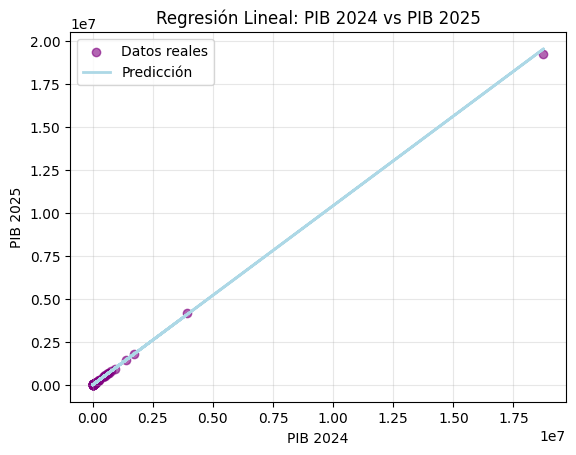

In [431]:
# Similar a: y = data_clean['Performance Index'], X = data_clean['Previous Scores']
y = pib_clean_nan['2025']  # Variable objetivo: PIB 2025
X = pib_clean_nan['2024'].values.reshape(-1, 1)  # Feature: PIB 2024

print("=== REGRESIÓN LINEAL SIMPLE ===")
print(f"y = PIB 2025")
print(f"X = PIB 2024")
print(f"Tamaño de X: {X.shape}")
print(f"Tamaño de y: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("\nCoefficient (Slope):", model.coef_[0])
print("Intercept:", model.intercept_)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R-squared Score:", r2)

# Gráfico
plt.scatter(X_test, y_test, color='purple', alpha=0.6, label='Datos reales')
plt.plot(X_test, y_pred, color='lightblue', linewidth=2, label='Predicción')
plt.xlabel('PIB 2024')
plt.ylabel('PIB 2025')
plt.title('Regresión Lineal: PIB 2024 vs PIB 2025')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [432]:
X_m = pib_clean_nan[['2020', '2021', '2022', '2023', '2024']]  # Features múltiples
y_m = pib_clean_nan['2025']  # Variable objetivo

print("=== REGRESIÓN LINEAL MÚLTIPLE ===")
print("Variables independientes: PIB 2020, 2021, 2022, 2023, 2024")
print("Variable dependiente: PIB 2025")

X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(X_m, y_m, test_size=0.25, random_state=42)

model_m = LinearRegression()
model_m.fit(X_m_train, y_m_train)
y_m_pred = model_m.predict(X_m_test)

mae_m = mean_absolute_error(y_m_test, y_m_pred)
mse_m = mean_squared_error(y_m_test, y_m_pred)
r2_m = r2_score(y_m_test, y_m_pred)

print("\nMean Absolute Error (MAE):", mae_m)
print("Mean Squared Error (MSE):", mse_m)
print("R-squared Score:", r2_m)

# Mostrar coeficientes
print("\nCoeficientes del modelo:")
for i, col in enumerate(X_m.columns):
    print(f"  {col}: {model_m.coef_[i]:.4f}")
print(f"Intercepto: {model_m.intercept_:.4f}")

=== REGRESIÓN LINEAL MÚLTIPLE ===
Variables independientes: PIB 2020, 2021, 2022, 2023, 2024
Variable dependiente: PIB 2025

Mean Absolute Error (MAE): 27515.425568057264
Mean Squared Error (MSE): 14824456729.037313
R-squared Score: 0.9980868821423786

Coeficientes del modelo:
  2020: 0.6590
  2021: -0.6277
  2022: 0.1355
  2023: -0.9373
  2024: 1.8414
Intercepto: 106.0385


=== REGRESIÓN POLINOMIAL ===

Grado 1:
  Mean Absolute Error (MAE): 18528.374840920096
  Mean Squared Error (MSE): 2451767457.7003493
  R-squared Score: 0.9996835958179248


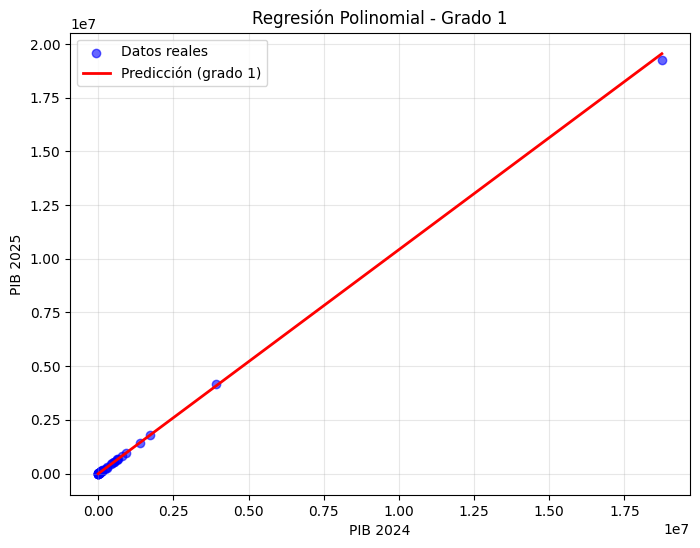


Grado 2:
  Mean Absolute Error (MAE): 14085.373594285134
  Mean Squared Error (MSE): 1536877194.2999318
  R-squared Score: 0.9998016637466635


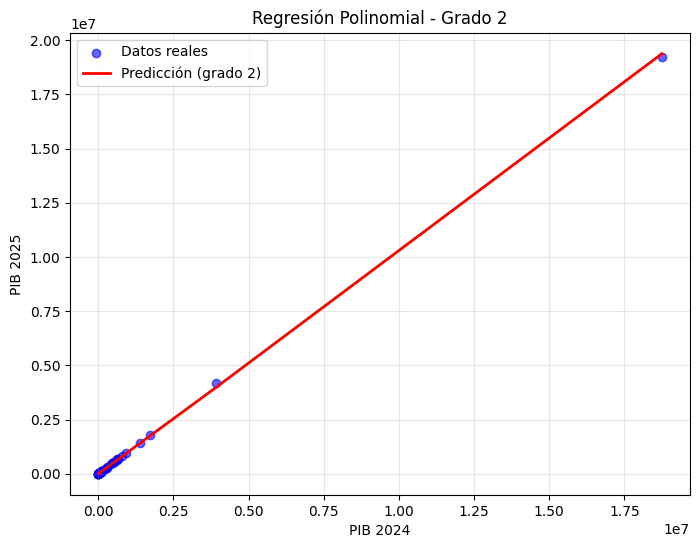


Grado 3:
  Mean Absolute Error (MAE): 752274.7507643191
  Mean Squared Error (MSE): 15946170306561.053
  R-squared Score: -1.0578766380286777


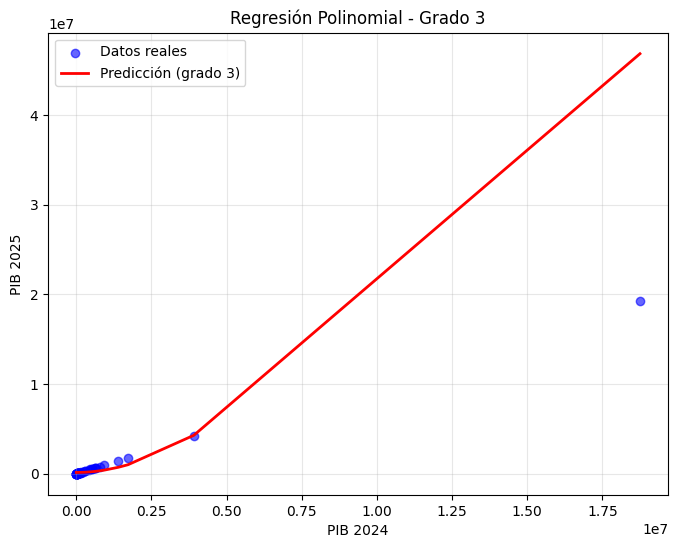


Grado 4:
  Mean Absolute Error (MAE): 3453430.5733764307
  Mean Squared Error (MSE): 495362381735391.06
  R-squared Score: -62.92724103241736

Grado 5:
  Mean Absolute Error (MAE): 14169682.316614218
  Mean Squared Error (MSE): 9266738554349880.0
  R-squared Score: -1194.886185529449


In [433]:
y_p = pib_clean_nan['2025']
X_p = pib_clean_nan['2024'].values.reshape(-1, 1)

X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(X_p, y_p, test_size=0.25, random_state=42)

print("=== REGRESIÓN POLINOMIAL ===")
lista_grados = [1, 2, 3, 4, 5]

for grado in lista_grados:
    # Transformación polinomial
    poly = PolynomialFeatures(degree=grado)
    X_poly_train = poly.fit_transform(X_p_train)
    X_poly_test = poly.transform(X_p_test)
    
    # Entrenar modelo con data transformada
    model_p = LinearRegression()
    model_p.fit(X_poly_train, y_p_train)
    
    # Predicciones
    y_p_pred = model_p.predict(X_poly_test)
    
    # Métricas
    mae_p = mean_absolute_error(y_p_test, y_p_pred)
    mse_p = mean_squared_error(y_p_test, y_p_pred)
    r2_p = r2_score(y_p_test, y_p_pred)
    
    # Prints
    print(f"\nGrado {grado}:")
    print("  Mean Absolute Error (MAE):", mae_p)
    print("  Mean Squared Error (MSE):", mse_p)
    print("  R-squared Score:", r2_p)
    
    # Gráfico solo para algunos grados para no saturar
    if grado in [1, 2, 3]:
        plt.figure(figsize=(8, 6))
        # Ordenar para línea continua
        sort_idx = X_p_test.flatten().argsort()
        X_sorted = X_p_test[sort_idx]
        y_pred_sorted = y_p_pred[sort_idx]
        y_test_sorted = y_p_test.iloc[sort_idx]
        
        # Datos reales
        plt.scatter(X_sorted, y_test_sorted, color='blue', alpha=0.6, label='Datos reales')
        # Línea de predicción
        plt.plot(X_sorted, y_pred_sorted, color='red', linewidth=2, label=f'Predicción (grado {grado})')
        
        plt.xlabel('PIB 2024')
        plt.ylabel('PIB 2025')
        plt.title(f'Regresión Polinomial - Grado {grado}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

# **PARTE 1: LEYENDO Y LIMPIANDO WHO_life_expectancy**

In [434]:
df_life_expectancy = pd.read_csv('data_2025/WHO_life_expectancy.csv')
df_life_expectancy.head()

,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Dim1,Value
0,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Male,48.7 [47.8-49.7]
1,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,CAF,Central African Republic,Year,2021,Sex,Male,49.6 [48.5-50.9]
2,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Both sexes,51.5 [50.5-52.6]
3,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,SWZ,Eswatini,Year,2021,Sex,Male,51.6 [50.7-52.8]
4,WHOSIS_000001,Life expectancy at birth (years),EMR,Eastern Mediterranean,Country,SOM,Somalia,Year,2021,Sex,Male,51.7 [50.6-53.1]


In [435]:
df_life_expectancy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24420 entries, 0 to 24419
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   IndicatorCode        24420 non-null  object
 1   Indicator            24420 non-null  object
 2   ParentLocationCode   24420 non-null  object
 3   ParentLocation       24420 non-null  object
 4   Location type        24420 non-null  object
 5   SpatialDimValueCode  24420 non-null  object
 6   Location             24420 non-null  object
 7   Period type          24420 non-null  object
 8   Period               24420 non-null  int64 
 9   Dim1 type            24420 non-null  object
 10  Dim1                 24420 non-null  object
 11  Value                24420 non-null  object
dtypes: int64(1), object(11)
memory usage: 2.2+ MB


No tiene datos NaN.

In [436]:
df_life_expectancy['IndicatorCode'].unique()

array(['WHOSIS_000001', 'WHOSIS_000015'], dtype=object)

In [437]:
df_life_expectancy['Indicator'].unique()
df_life_e = df_life_expectancy.copy()

Notamos que los datos son 

In [438]:
# Cambiamos los datos a categóricos
df_life_e['IndicatorCode'] = df_life_e['IndicatorCode'].astype('category')
df_life_e['Indicator'] = df_life_e['Indicator'].astype('category')

df_life_e.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24420 entries, 0 to 24419
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   IndicatorCode        24420 non-null  category
 1   Indicator            24420 non-null  category
 2   ParentLocationCode   24420 non-null  object  
 3   ParentLocation       24420 non-null  object  
 4   Location type        24420 non-null  object  
 5   SpatialDimValueCode  24420 non-null  object  
 6   Location             24420 non-null  object  
 7   Period type          24420 non-null  object  
 8   Period               24420 non-null  int64   
 9   Dim1 type            24420 non-null  object  
 10  Dim1                 24420 non-null  object  
 11  Value                24420 non-null  object  
dtypes: category(2), int64(1), object(9)
memory usage: 1.9+ MB


In [439]:
df_life_e['Dim1'].unique()

array(['Male', 'Both sexes', 'Female'], dtype=object)

In [440]:
df_life_e['Dim1'] = df_life_e['Dim1'].astype('category')
df_life_e.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24420 entries, 0 to 24419
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   IndicatorCode        24420 non-null  category
 1   Indicator            24420 non-null  category
 2   ParentLocationCode   24420 non-null  object  
 3   ParentLocation       24420 non-null  object  
 4   Location type        24420 non-null  object  
 5   SpatialDimValueCode  24420 non-null  object  
 6   Location             24420 non-null  object  
 7   Period type          24420 non-null  object  
 8   Period               24420 non-null  int64   
 9   Dim1 type            24420 non-null  object  
 10  Dim1                 24420 non-null  category
 11  Value                24420 non-null  object  
dtypes: category(3), int64(1), object(8)
memory usage: 1.7+ MB


In [441]:
pib_clean_nan.head()

,Country,2020,2021,2022,2023,2024,2025
0,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0
1,Algeria,164774,185850.0,225709.0,247789.0,264913.0,268885.0
2,Andorra,2885,3325.0,3376.0,3786.0,4038.0,4035.0
3,Angola,66521,84375.0,142442.0,109764.0,115946.0,113343.0
4,Antigua and Barbuda,1412,1602.0,1867.0,2006.0,2225.0,2373.0


In [442]:
df_life_e = df_life_e.rename(columns={'Location': 'Country'})
df_me = pd.merge(pib_clean_nan, df_life_e, on='Country', how='inner')
df_me.head()

,Country,2020,2021,2022,2023,2024,2025,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Period type,Period,Dim1 type,Dim1,Value
0,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000001,Life expectancy at birth (years),EUR,Europe,Country,ALB,Year,2021,Sex,Male,74.4 [73.9-74.9]
1,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000001,Life expectancy at birth (years),EUR,Europe,Country,ALB,Year,2021,Sex,Both sexes,76.4 [76.1-76.9]
2,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000001,Life expectancy at birth (years),EUR,Europe,Country,ALB,Year,2021,Sex,Female,78.6 [78.4-79.0]
3,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000015,Life expectancy at age 60 (years),EUR,Europe,Country,ALB,Year,2021,Sex,Male,18.7 [18.1-19.1]
4,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000015,Life expectancy at age 60 (years),EUR,Europe,Country,ALB,Year,2021,Sex,Both sexes,19.9 [19.6-20.4]


# **EDA merge**

In [443]:
# Crear columna 'Promedio' cortando los corchetes
df_me['Promedio edad'] = df_me['Value'].str.split('[').str[0]

# Convertir a numérico
df_me['Promedio edad'] = pd.to_numeric(df_me['Promedio edad'])

df_me.head()

,Country,2020,2021,2022,2023,2024,2025,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Period type,Period,Dim1 type,Dim1,Value,Promedio edad
0,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000001,Life expectancy at birth (years),EUR,Europe,Country,ALB,Year,2021,Sex,Male,74.4 [73.9-74.9],74.4
1,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000001,Life expectancy at birth (years),EUR,Europe,Country,ALB,Year,2021,Sex,Both sexes,76.4 [76.1-76.9],76.4
2,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000001,Life expectancy at birth (years),EUR,Europe,Country,ALB,Year,2021,Sex,Female,78.6 [78.4-79.0],78.6
3,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000015,Life expectancy at age 60 (years),EUR,Europe,Country,ALB,Year,2021,Sex,Male,18.7 [18.1-19.1],18.7
4,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000015,Life expectancy at age 60 (years),EUR,Europe,Country,ALB,Year,2021,Sex,Both sexes,19.9 [19.6-20.4],19.9


In [444]:
df_me.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20592 entries, 0 to 20591
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Country              20592 non-null  object  
 1   2020                 20592 non-null  int64   
 2   2021                 20592 non-null  float64 
 3   2022                 20592 non-null  float64 
 4   2023                 20592 non-null  float64 
 5   2024                 20592 non-null  float64 
 6   2025                 20592 non-null  float64 
 7   IndicatorCode        20592 non-null  category
 8   Indicator            20592 non-null  category
 9   ParentLocationCode   20592 non-null  object  
 10  ParentLocation       20592 non-null  object  
 11  Location type        20592 non-null  object  
 12  SpatialDimValueCode  20592 non-null  object  
 13  Period type          20592 non-null  object  
 14  Period               20592 non-null  int64   
 15  Dim1 type          

In [445]:
df_merged = df_me[df_me['Period'] == 2021].copy()
df_merged = df_merged[df_merged['Dim1'] == 'Both sexes']
df_merged = df_merged[df_merged['IndicatorCode'] == 'WHOSIS_000015']
df_merged.reset_index(drop=True, inplace=True)
df_merged['Log PIB 2021'] = np.log(df_merged['2021'])
df_merged.head()

,Country,2020,2021,2022,2023,2024,2025,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Period type,Period,Dim1 type,Dim1,Value,Promedio edad,Log PIB 2021
0,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000015,Life expectancy at age 60 (years),EUR,Europe,Country,ALB,Year,2021,Sex,Both sexes,19.9 [19.6-20.4],19.9,9.802893
1,Algeria,164774,185850.0,225709.0,247789.0,264913.0,268885.0,WHOSIS_000015,Life expectancy at age 60 (years),AFR,Africa,Country,DZA,Year,2021,Sex,Both sexes,21.0 [20.7-21.3],21.0,12.132695
2,Angola,66521,84375.0,142442.0,109764.0,115946.0,113343.0,WHOSIS_000015,Life expectancy at age 60 (years),AFR,Africa,Country,AGO,Year,2021,Sex,Both sexes,15.8 [15.2-16.6],15.8,11.343026
3,Antigua and Barbuda,1412,1602.0,1867.0,2006.0,2225.0,2373.0,WHOSIS_000015,Life expectancy at age 60 (years),AMR,Americas,Country,ATG,Year,2021,Sex,Both sexes,20.9,20.9,7.379008
4,Argentina,385218,486040.0,632318.0,645511.0,632145.0,683533.0,WHOSIS_000015,Life expectancy at age 60 (years),AMR,Americas,Country,ARG,Year,2021,Sex,Both sexes,19.6 [19.5-19.7],19.6,13.094046


In [446]:
df_merged['Period'].unique()

array([2021])

In [447]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Country              156 non-null    object  
 1   2020                 156 non-null    int64   
 2   2021                 156 non-null    float64 
 3   2022                 156 non-null    float64 
 4   2023                 156 non-null    float64 
 5   2024                 156 non-null    float64 
 6   2025                 156 non-null    float64 
 7   IndicatorCode        156 non-null    category
 8   Indicator            156 non-null    category
 9   ParentLocationCode   156 non-null    object  
 10  ParentLocation       156 non-null    object  
 11  Location type        156 non-null    object  
 12  SpatialDimValueCode  156 non-null    object  
 13  Period type          156 non-null    object  
 14  Period               156 non-null    int64   
 15  Dim1 type            15

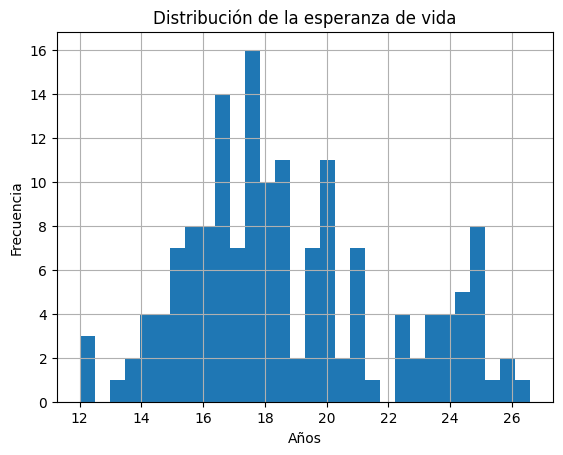

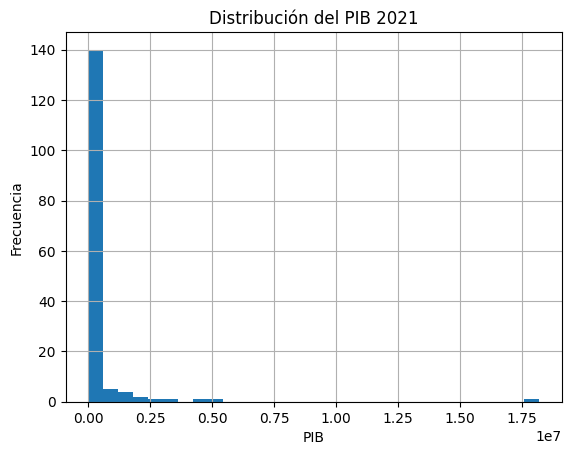

In [448]:
df_merged['Promedio edad'].hist(bins=30)
plt.title("Distribución de la esperanza de vida")
plt.xlabel("Años")
plt.ylabel("Frecuencia")
plt.show()

df_merged["2021"].hist(bins=30)
plt.title("Distribución del PIB 2021")
plt.xlabel("PIB")
plt.ylabel("Frecuencia")
plt.show()

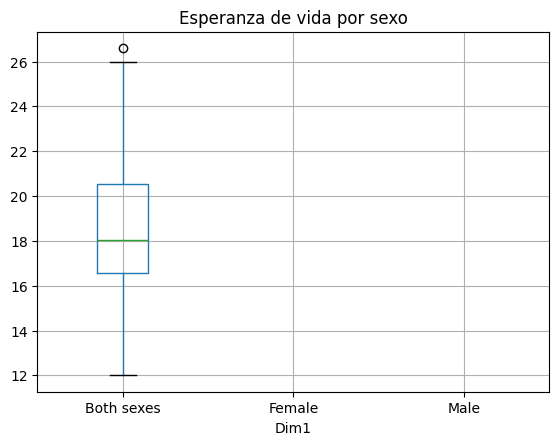

In [449]:
df_merged.boxplot(column="Promedio edad", by="Dim1")
plt.title("Esperanza de vida por sexo")
plt.suptitle("")
plt.show()

In [450]:
df_merged.head()

,Country,2020,2021,2022,2023,2024,2025,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Period type,Period,Dim1 type,Dim1,Value,Promedio edad,Log PIB 2021
0,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000015,Life expectancy at age 60 (years),EUR,Europe,Country,ALB,Year,2021,Sex,Both sexes,19.9 [19.6-20.4],19.9,9.802893
1,Algeria,164774,185850.0,225709.0,247789.0,264913.0,268885.0,WHOSIS_000015,Life expectancy at age 60 (years),AFR,Africa,Country,DZA,Year,2021,Sex,Both sexes,21.0 [20.7-21.3],21.0,12.132695
2,Angola,66521,84375.0,142442.0,109764.0,115946.0,113343.0,WHOSIS_000015,Life expectancy at age 60 (years),AFR,Africa,Country,AGO,Year,2021,Sex,Both sexes,15.8 [15.2-16.6],15.8,11.343026
3,Antigua and Barbuda,1412,1602.0,1867.0,2006.0,2225.0,2373.0,WHOSIS_000015,Life expectancy at age 60 (years),AMR,Americas,Country,ATG,Year,2021,Sex,Both sexes,20.9,20.9,7.379008
4,Argentina,385218,486040.0,632318.0,645511.0,632145.0,683533.0,WHOSIS_000015,Life expectancy at age 60 (years),AMR,Americas,Country,ARG,Year,2021,Sex,Both sexes,19.6 [19.5-19.7],19.6,13.094046


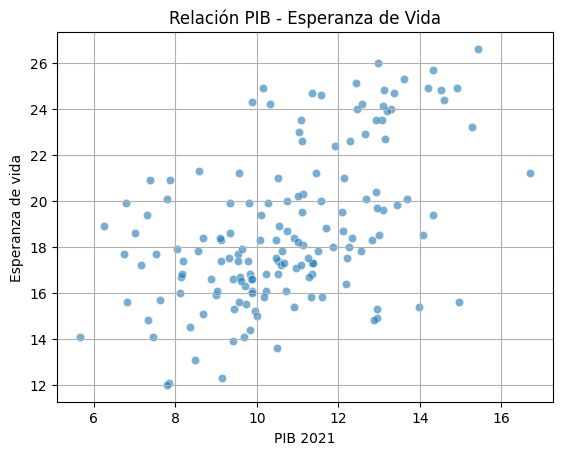

In [451]:
sns.scatterplot(data=df_merged, x="Log PIB 2021", y="Promedio edad", alpha=0.6)
plt.xlabel("PIB 2021")
plt.ylabel("Esperanza de vida")
plt.title("Relación PIB - Esperanza de Vida")
plt.grid(True)
plt.show()

In [452]:
df_merged[["2021", "Promedio edad"]].corr()

,2021,Promedio edad
2021,1.000000,0.228072
Promedio edad,0.228072,1.000000


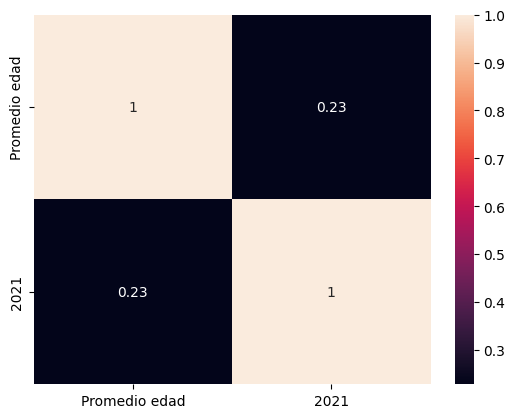

In [453]:
sns.heatmap(df_merged[['Promedio edad', "2021"]].corr(), annot=True)
plt.show()

# **REGRESIÓN LINEAL**

In [455]:
X = df_merged['Log PIB 2021'].values.reshape(-1, 1)  # Variable independiente
y = df_merged['Promedio edad'].values  # Variable dependiente

print(f"Datos: {X.shape[0]} observaciones")

# Split train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Datos: 156 observaciones
Train: (117, 1), Test: (39, 1)


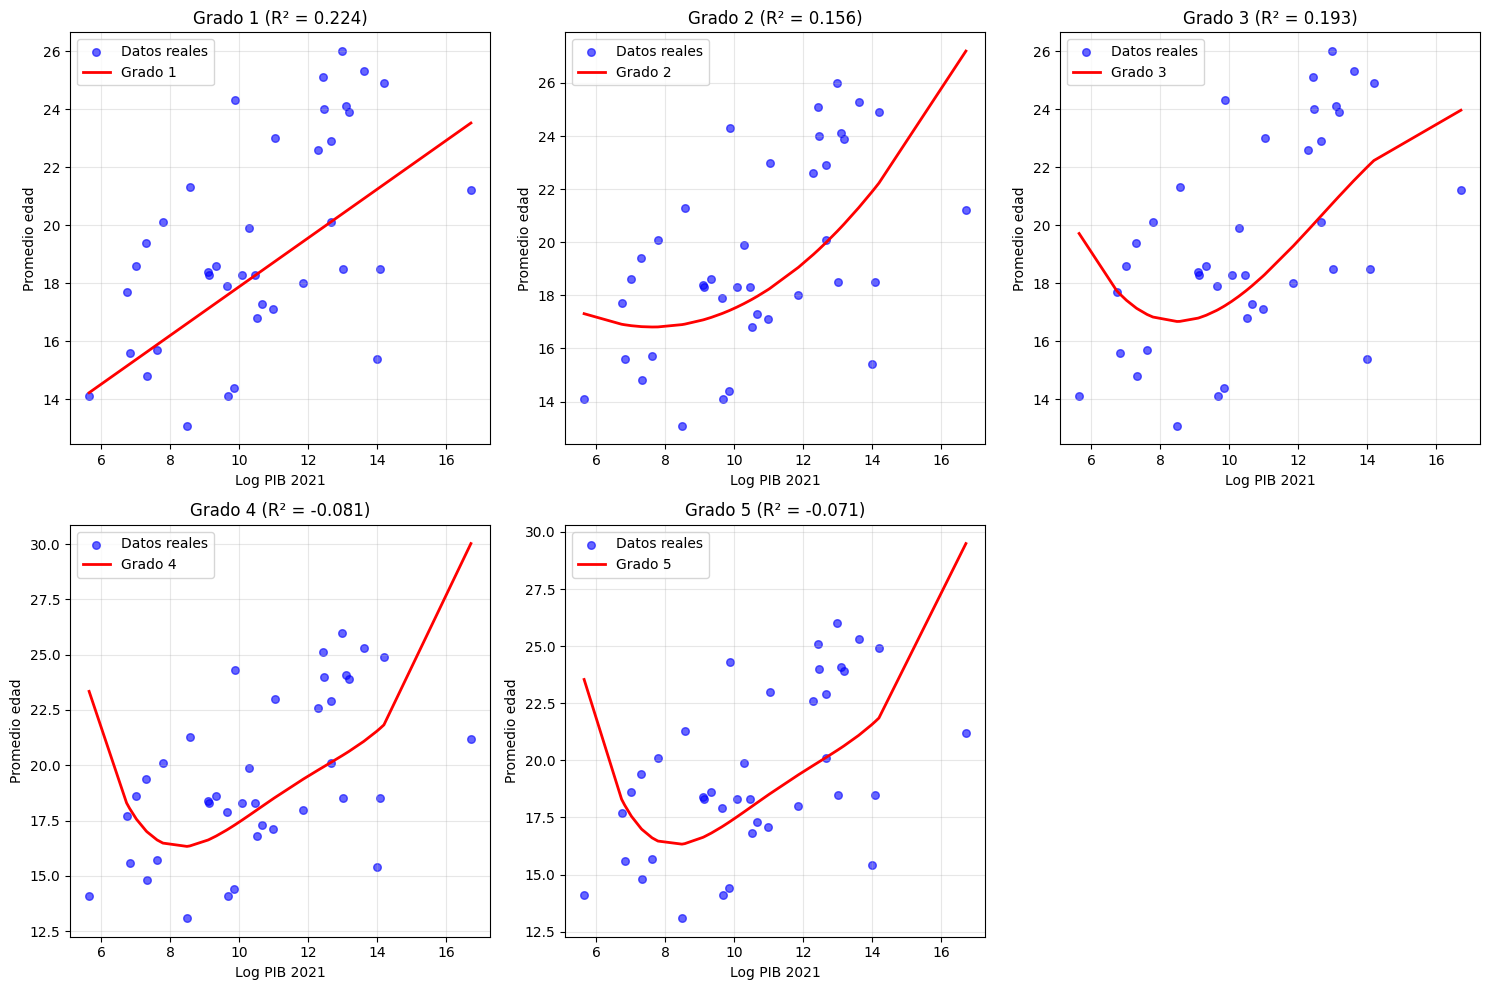

In [456]:
# Probar diferentes grados polinomiales
grados = [1, 2, 3, 4, 5]
resultados = []

plt.figure(figsize=(15, 10))

for i, grado in enumerate(grados):
    # Transformación polinomial
    poly = PolynomialFeatures(degree=grado)
    X_poly_train = poly.fit_transform(X_train)
    X_poly_test = poly.transform(X_test)
    
    # Entrenar modelo
    model_poly = LinearRegression()
    model_poly.fit(X_poly_train, y_train)
    
    # Predicciones
    y_pred = model_poly.predict(X_poly_test)
    
    # Métricas
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Guardar resultados
    resultados.append({
        'Grado': grado,
        'MAE': mae,
        'MSE': mse,
        'R²': r2,
        'Coeficientes': model_poly.coef_,
        'Intercepto': model_poly.intercept_
    })
    
    # Gráfico
    plt.subplot(2, 3, i+1)
    
    # Ordenar para línea continua
    sort_idx = X_test.flatten().argsort()
    X_sorted = X_test[sort_idx]
    y_pred_sorted = y_pred[sort_idx]
    y_test_sorted = y_test[sort_idx]
    
    # Datos reales
    plt.scatter(X_sorted, y_test_sorted, alpha=0.6, color='blue', label='Datos reales', s=30)
    # Línea de predicción
    plt.plot(X_sorted, y_pred_sorted, color='red', linewidth=2, label=f'Grado {grado}')
    
    plt.xlabel('Log PIB 2021')
    plt.ylabel('Promedio edad')
    plt.title(f'Grado {grado} (R² = {r2:.3f})')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()